# EXAMEN I — ANÁLISIS DE ACCIDENTES DE TRÁFICO EN ECUADOR

## Tecnología Superior en Desarrollo de Software

### Asignatura: Análisis de Datos

#### CORRECCIÓN
---

|                            |            |
| -------------------------- | ---------- |
| **Nombre del estudiante:** |Sebastián Tobar|
| **Fecha:**                 |01/06/2026            |
| **Tiempo disponible:**     | 3 horas    |
| **Puntaje total:**         | 100 puntos |


## 📋 INSTRUCCIONES GENERALES

- Complete **únicamente** las celdas de código y las celdas Markdown habilitadas con `✏️ Tu respuesta:`.
- Los archivos de datos se encuentran en la carpeta **`data/`** ubicada en el mismo directorio que este notebook.
- Todos los gráficos deben incluir **título** y **etiquetas en los ejes**.

> ⚠️ Los datos corresponden a registros **simulados** de accidentes de tráfico del Ecuador (2019 – 2023),
> distribuidos por región geográfica en distintos formatos de archivo.


## 📁 DESCRIPCIÓN DE LOS ARCHIVOS Y COLUMNAS

Los datos provienen de distintas fuentes del sistema de registro de la **Agencia Nacional de Tránsito (ANT) del Ecuador**.

### Columnas del dataset

| Columna                  | Tipo           | Descripción                                                      |
| ------------------------ | -------------- | ---------------------------------------------------------------- |
| `id_accidente`           | int            | Identificador único del registro                                 |
| `fecha`                  | str → datetime | Fecha del accidente (`YYYY-MM-DD`)                               |
| `provincia`              | str            | Provincia donde ocurrió el accidente                             |
| `canton`                 | str            | Cantón dentro de la provincia                                    |
| `tipo_accidente`         | str            | Tipo de accidente (Choque frontal, Atropello, Volcamiento, etc.) |
| `causa_probable`         | str            | Causa probable del accidente                                     |
| `gravedad`               | str            | Nivel de gravedad: `Leve`, `Grave`, `Fatal`                      |
| `victimas_fatales`       | float          | Número de víctimas mortales                                      |
| `heridos`                | float          | Número de heridos                                                |
| `vehiculos_involucrados` | float          | Vehículos involucrados                                           |
| `condicion_climatica`    | str            | Condición climática al momento del hecho                         |
| `tipo_via`               | str            | Tipo de vía: Urbana, Rural, Autopista, etc.                      |

### Archivos disponibles en `data/`

| Archivo                        | Formato                                                    | Región cubierta                        |
| ------------------------------ | ---------------------------------------------------------- | -------------------------------------- |
| `accidentes_costa.csv`         | CSV                                                        | Guayas, Manabí, El Oro, Los Ríos       |
| `accidentes_sierra.xlsx`       | Excel                                                      | Pichincha, Azuay, Tungurahua, Imbabura |
| `accidentes.json`              | Fuente de diferentes regiones con datos en estructura JSON | Loja, Cotopaxi, Chimborazo, Bolívar    |
| `accidentes_amazonia.sqlite`   | SQLite                                                     | Sucumbíos, Napo, Orellana              |
| `accidentes_feriados.xml`      | XML                                                        | Todo Ecuador — solo días festivos      |
| `accidentes_insularMongo.json` | MONGO                                                      | Region Insular                         |


---

# PARTE 1: EXTRACCIÓN DE DATOS _(15 puntos)_


## 1.1 Importar librerías


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import urllib.parse
from sqlalchemy import create_engine

## 1.2 Cargar desde CSV _(2 pts)_

Cargue `data/accidentes_costa.csv` a un Dataframe. Agregue la columna `origen = 'CSV'`.
Muestre la cantidad de registros cargados.


In [2]:
# Su código aquí
df_csv = pd.read_csv('./data/accidentes_costa.csv')
df_csv['origen'] = 'CSV'
print(f'{len(df_csv)} registros')
df_csv.head(5)

232 registros


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,1,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,NaN,CSV
1,2,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV
2,3,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV
3,4,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV
4,5,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV


## 1.3 Cargar desde Excel _(2 pts)_

Cargue `data/accidentes_sierra.xlsx` a un Dataframe. Agregue la columna `origen = 'EXCEL'`.
Muestre la cantidad de registros cargados.


In [3]:
# Su código aquí
df_excel = pd.read_excel('./data/accidentes_sierra.xlsx')
df_excel['origen'] = 'EXCEL'
print(f'{len(df_excel)} registros cargados')
df_excel.head(5)

90 registros cargados


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,830,2019-07-03,Galapagos,Espanola,Rozamiento,Estado de embriaguez,Grave,1.0,1.0,1.0,Neblina,Secundaria,EXCEL
1,831,2023-10-07,Galapagos,San Cristobal,Rozamiento,No respetar seniales,Leve,0.0,4.0,2.0,Nublado,Rural,EXCEL
2,832,2020-02-10,Galapagos,Santa Cruz,Rozamiento,Mal estado de la via,Grave,0.0,NaN,NaN,Neblina,Secundaria,EXCEL
3,833,2021-10-27,Galapagos,Santa Cruz,Caida de ocupante,Mal estado de la via,Leve,0.0,1.0,3.0,Lluvioso,Rural,EXCEL
4,834,2019-01-12,Galapagos,Santa Cruz,Volcamiento,Exceso de velocidad,Grave,NaN,3.0,2.0,Nublado,Secundaria,EXCEL


## 1.4 Cargar desde JSON — simula una API _(2 pts)_

Cargue `data/accidentes.json` a un Dataframe.

> **Pista:** Los registros están dentro de la clave `"data"` del JSON.

Agregue la columna `origen = 'JSON_API'`. Muestre la cantidad de registros cargados.


In [4]:
# Su código aquí
import json
with open('./data/accidentes.json') as f:
    data = json.load(f)
df_api = pd.DataFrame(data['data'])
df_api['origen'] = 'JSON_API'

print(f'{len(df_api)} registros cargados')

df_api.head(5)

160 registros cargados


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,421,2021-12-07,Bolivar,San Miguel,Choque lateral,Estado de embriaguez,Grave,1,1,4,Nublado,Secundaria,JSON_API
1,422,2019-06-09,Loja,Loja,Choque con objeto fijo,Estado de embriaguez,Grave,2,3,2,Neblina,Urbana,JSON_API
2,423,2023-03-26,Bolivar,Guaranda,Choque con objeto fijo,,Leve,,,1,Soleado,Urbana,JSON_API
3,424,2023-10-18,Cotopaxi,Salcedo,Choque con objeto fijo,Mal estado de la via,Leve,0,3,1,Lluvioso,Rural,JSON_API
4,425,2021-10-29,Loja,Calvas,Atropello,,Leve,0,0,3,Lluvioso,Rural,JSON_API


## 1.5 Cargar desde SQLite _(2 pts)_

Conéctese a `data/accidentes_amazonia.sqlite` y lea la tabla `accidentes_amazonia` cargue los datos a un Dataframe .
Agregue la columna `origen = 'SQLITE'`. Muestre la cantidad de registros cargados.


In [5]:
# Su código aquí
import sqlite3
con_sqlite = sqlite3.connect('./data/accidentes_amazonia.sqlite')
df_sqlite = pd.read_sql('select * from accidentes_amazonia', con_sqlite)
con_sqlite.close()
df_sqlite['origen'] = 'SQLITE'

print(f'{len(df_sqlite)} registros cargados')
df_sqlite.head(5)

232 registros cargados


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,1,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,None,SQLITE
1,2,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,SQLITE
2,3,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,SQLITE
3,4,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,SQLITE
4,5,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,SQLITE


## 1.6 Cargar desde XML _(2 pts)_

Cargue `data/accidentes_feriados.xml` usando `xml.etree.ElementTree` a un Dataframe.

> 💡 **Pista:** Cada registro está en una etiqueta `<accidente>`.

Agregue la columna `origen = 'XML'`. Muestre la cantidad de registros cargados.


In [6]:
# Su código aquí
df_xml = pd.read_xml('./data/accidentes_feriados.xml', xpath='accidente')
df_xml['origen'] = 'XML'
print(f'{len(df_xml)} registros cargados')

df_xml.head(5)

130 registros cargados


,id,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,nombre_feriado,origen
0,701,2019-08-10,Orellana,Loreto,Volcamiento,No respetar seniales,Leve,0.0,4.0,4.0,Soleado,Autopista,Independencia de Quito,XML
1,702,2021-10-09,Sucumbios,Nueva Loja,Choque frontal,Mal estado de la via,Leve,0.0,0.0,4.0,Soleado,Rural,Independencia de Guayaquil,XML
2,703,2022-10-12,Imbabura,Ibarra,Rozamiento,None,Leve,0.0,5.0,NaN,Neblina,Rural,Dia de la Raza,XML
3,704,2022-05-24,Guayas,Daule,Atropello,Mal estado de la via,Leve,0.0,6.0,4.0,Neblina,Autopista,Batalla de Pichincha,XML
4,705,2023-04-08,Orellana,Loreto,Atropello,Exceso de velocidad,Leve,NaN,35.0,15.0,Soleado,Rural,Semana Santa,XML


## 1.7 Cargar desde MONGO DB _(2 pts)_

Cargue `data/accidentes_insularMongo.json` a MONGO DB y luego realize una conexión para la extracción de datos desde Mongo  
Tip: El documento envoltorio que tiene los accidentes anidados es el campo `data` , tomar en cuenta para poder extraer correctamente del anidamiento

Los datos extraidos almacenelos en un DataFrame y agregue la columna `origen = 'MONGO'`. Muestre la cantidad de registros cargados.


In [7]:
from pymongo import MongoClient
con_mongo = MongoClient('mongodb://localhost:27017/')
db = con_mongo['accidentes']
coleccion = db['accidentes']
doc = coleccion.find_one({'data.provincia': 'Galapagos'})
df_mongo = pd.DataFrame(doc['data'])
df_mongo['origen'] = 'MONGO'
print(f'{len(df_mongo)} registros cargados')
df_mongo.head(5)

90 registros cargados


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen
0,830,2019-07-03,Galapagos,Espanola,Rozamiento,Estado de embriaguez,Grave,1,1,1,Neblina,Secundaria,MONGO
1,831,2023-10-07,Galapagos,San Cristobal,Rozamiento,No respetar seniales,Leve,0,4,2,Nublado,Rural,MONGO
2,832,2020-02-10,Galapagos,Santa Cruz,Rozamiento,Mal estado de la via,Grave,0,,,Neblina,Secundaria,MONGO
3,833,2021-10-27,Galapagos,Santa Cruz,Caida de ocupante,Mal estado de la via,Leve,0,1,3,Lluvioso,Rural,MONGO
4,834,2019-01-12,Galapagos,Santa Cruz,Volcamiento,Exceso de velocidad,Grave,,3,2,Nublado,Secundaria,MONGO


## 1.8 Concatenar todas las fuentes _(3 pts)_

Una todos los DataFrames en **`df_accidentes`** usando `pd.concat()` con `ignore_index=True`.
Muestre el total de registros y cuántos vinieron de cada fuente (`value_counts` sobre `origen`).


In [8]:
# Su código aquí
df_accidentes = pd.concat([df_csv,df_excel,df_api,df_sqlite,df_xml,df_mongo], ignore_index=True)
print(f'Total de registros: {len(df_accidentes)}')
display(df_accidentes.value_counts('origen'))

Total de registros: 934


origen
CSV         232
SQLITE      232
JSON_API    160
XML         130
EXCEL        90
MONGO        90
Name: count, dtype: int64

---

# PARTE 2: ANÁLISIS EXPLORATORIO INICIAL _(10 puntos)_


## 2.1 Estructura del dataset _(3 pts)_

Muestre: número de filas y columnas, tipos de datos de cada columna y las primeras 5 filas.


In [9]:
# Su código aquí
print(f' {df_accidentes.shape}')
print(df_accidentes.info())
df_accidentes.head(5)

 (934, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_accidente            804 non-null    float64
 1   fecha                   934 non-null    object 
 2   provincia               934 non-null    object 
 3   canton                  934 non-null    object 
 4   tipo_accidente          934 non-null    object 
 5   causa_probable          879 non-null    object 
 6   gravedad                934 non-null    object 
 7   victimas_fatales        884 non-null    object 
 8   heridos                 899 non-null    object 
 9   vehiculos_involucrados  915 non-null    object 
 10  condicion_climatica     934 non-null    object 
 11  tipo_via                884 non-null    object 
 12  origen                  934 non-null    object 
 13  id                      130 non-null    float64
 14  nombre_feriado          130 non

,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,id,nombre_feriado
0,1.0,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,NaN,4.0,1.0,Soleado,NaN,CSV,NaN,NaN
1,2.0,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV,NaN,NaN
2,3.0,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV,NaN,NaN
3,4.0,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV,NaN,NaN
4,5.0,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV,NaN,NaN


## 2.2 Estadísticas descriptivas _(2 pts)_

Muestre `describe()` para variables numéricas **y** categóricas.


In [10]:
# Su código aquí
display(df_accidentes.describe())
display(df_accidentes.describe(include='all'))

,id_accidente,id
count,804.000000,130.000000
mean,356.850746,765.500000
std,321.491740,37.671829
min,1.000000,701.000000
25%,89.000000,733.250000
50%,189.500000,765.500000
75%,559.250000,797.750000
max,919.000000,830.000000


,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,id,nombre_feriado
count,804.000000,934,934,934,934,879,934,884.0,899.0,915.0,934,884,934,130.000000,130
unique,NaN,443,16,70,7,8,3,7.0,17.0,11.0,4,6,6,NaN,11
top,NaN,2023-10-09,Galapagos,San Cristobal,Choque frontal,Estado de embriaguez,Leve,0.0,5.0,1.0,Neblina,Urbana,CSV,NaN,Carnaval
freq,NaN,9,180,50,153,147,515,560.0,113.0,252.0,248,180,232,NaN,24
mean,356.850746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,765.500000,NaN
std,321.491740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.671829,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,701.000000,NaN
25%,89.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,733.250000,NaN
50%,189.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,765.500000,NaN
75%,559.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,797.750000,NaN


## 2.3 Análisis de valores nulos _(2 pts)_

Muestre el número **y** porcentaje de nulos por columna.
Ordene el resultado de mayor a menor porcentaje de nulos.


In [11]:
# Su código aquí
display(df_accidentes.isnull().sum().sort_values(ascending=False))
display(round(df_accidentes.isnull().sum() / len(df_accidentes) * 100, 2).sort_values(ascending=False))

id                        804
nombre_feriado            804
id_accidente              130
causa_probable             55
victimas_fatales           50
tipo_via                   50
heridos                    35
vehiculos_involucrados     19
fecha                       0
provincia                   0
canton                      0
tipo_accidente              0
gravedad                    0
condicion_climatica         0
origen                      0
dtype: int64

id                        86.08
nombre_feriado            86.08
id_accidente              13.92
causa_probable             5.89
victimas_fatales           5.35
tipo_via                   5.35
heridos                    3.75
vehiculos_involucrados     2.03
fecha                      0.00
provincia                  0.00
canton                     0.00
tipo_accidente             0.00
gravedad                   0.00
condicion_climatica        0.00
origen                     0.00
dtype: float64

## 2.4 Manejo de fechas _(3 pts)_

1. Convierta la columna `fecha` a tipo `datetime` con `pd.to_datetime()`.
2. Extraiga el **año** en la columna `anio`.
3. Extraiga el **mes** en la columna `mes`.
4. Extraiga el **día de la semana** en la columna `dia_semana` (0 = Lunes, 6 = Domingo).

Muestre las nuevas columnas con `.head()`.


In [12]:
# Su código aquí
df_accidentes['fecha'] = pd.to_datetime(df_accidentes['fecha'])
df_accidentes['anio'] = df_accidentes['fecha'].dt.year
df_accidentes['mes'] = df_accidentes['fecha'].dt.month
dias = ({
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
})
df_accidentes['dia_semana'] = df_accidentes['fecha'].dt.day_of_week.map(dias)
display(df_accidentes[['fecha','anio','mes','dia_semana']].head())

,fecha,anio,mes,dia_semana
0,2019-07-11,2019,7,Jueves
1,2019-07-29,2019,7,Lunes
2,2022-12-13,2022,12,Martes
3,2022-06-01,2022,6,Miércoles
4,2021-04-01,2021,4,Jueves


---

# PARTE 3: CÁLCULO DE OUTLIERS _(15 puntos)_


## 3.1 Detección de outliers — método IQR _(10 pts)_

Aplique el método IQR a **todas las columnas numéricas** de `df_accidentes`.
Para cada columna calcule y guarde en un DataFrame llamado **`df_outliers`**:

| Campo               | Descripción                    |
| ------------------- | ------------------------------ |
| `columna`           | Nombre de la columna           |
| `Q1`                | Percentil 25                   |
| `Q3`                | Percentil 75                   |
| `IQR`               | Q3 − Q1                        |
| `limite_inferior`   | `max(0, Q1 − 1.5 × IQR)`       |
| `limite_superior`   | `Q3 + 1.5 × IQR`               |
| `cantidad_outliers` | Registros fuera de los límites |

Ordene `df_outliers` de **mayor a menor** cantidad de outliers y muéstrelo.


In [13]:
# Su código aquí
colum = ['victimas_fatales', 'heridos', 'vehiculos_involucrados']

# Convertir columnas a numéricas
df_accidentes[colum] = df_accidentes[colum].apply(pd.to_numeric, errors='coerce')

resumen_outliers = []

for col in colum:
    q1 = df_accidentes[col].quantile(0.25)
    q3 = df_accidentes[col].quantile(0.75)
    iqr = q3 - q1

    lim_inf = max(0, q1 - 1.5 * iqr)
    lim_sup = q3 + 1.5 * iqr

    outliers = df_accidentes[(df_accidentes[col] < lim_inf) | (df_accidentes[col] > lim_sup)]

    resumen_outliers.append({
        'columna': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite inferior': lim_inf,
        'limite superior': lim_sup,
        'cantidad_outliers': outliers.shape[0]
    })

display(
    pd.DataFrame(resumen_outliers)
    .sort_values('cantidad_outliers', ascending=False))

,columna,Q1,Q3,IQR,limite inferior,limite superior,cantidad_outliers
0,victimas_fatales,0.0,1.0,1.0,0,2.5,73
2,vehiculos_involucrados,1.0,3.0,2.0,0,6.0,26
1,heridos,2.0,6.0,4.0,0,12.0,12


## 3.2 BoxPlot de variables con outliers _(5 pts)_

Cree un diagrama de caja (BoxPlot) con Seaborn para las columnas numéricas.
El gráfico debe incluir **título** y **etiquetas de los ejes**.


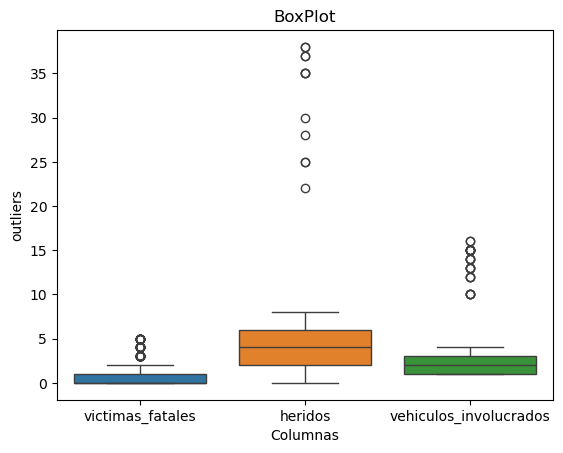

In [14]:
# Su código aquí
sns.boxplot(data=df_accidentes[['victimas_fatales', 'heridos', 'vehiculos_involucrados']])
plt.title('BoxPlot')
plt.ylabel('outliers')
plt.xlabel('Columnas')
plt.show()

---

# PARTE 4: LIMPIEZA DE DATOS _(15 puntos)_


## 4.1 Proceso de limpieza _(11 pts)_

Aplique los siguientes pasos sobre `df_accidentes` y guarde el resultado en **`df_limpio`**:

1. **Elimine los duplicados exactos.** Imprima cuántos fueron eliminados.
2. **Impute nulos en columnas categóricas** con el valor `'Desconocido'`.
3. **Impute nulos en columnas numéricas** con la **mediana** de cada columna.
4. **Verifique** que `df_limpio` no tenga valores nulos (`isnull().sum()`).


In [15]:
# Su código aquí
df_limpio = df_accidentes.copy()
filas= len(df_limpio)
df_limpio = df_limpio.drop_duplicates()
filas_d = len(df_limpio)
print('Eliminados: ', filas - filas_d)

col_c = df_limpio.select_dtypes(include='object').columns
df_limpio[col_c] = df_limpio[col_c].fillna('Desconocido')

col_num = df_limpio.select_dtypes(include='number').columns
df_limpio[col_num] = df_limpio[col_num].fillna(df_limpio[col_num].median())

Eliminados:  24


## 4.2 Pregunta Conceptual _(4 pts)_

Para imputar valores nulos en columnas numéricas, ¿cuándo es recomendable usar:

- La **media**
- La **mediana**
- La **moda**


**✏️ Tu respuesta:** = La media se usa cuando se quiere conservar el promedio general de la variable.

La mediana se usa cuanado hay valores muy diferentes, como los outliers.

La moda se usa cuando se quiere emplear el valor más frecuente.


---

# PARTE 5: EDA PROFUNDO — RESPUESTA DE PREGUNTAS _(25 puntos)_

> Use **`df_limpio`** para responder cada pregunta. Acompañe cada respuesta con una
> breve **interpretación en Markdown** (2-3 oraciones).


### Pregunta 1 _(5 pts)_

¿Cuál es el **Top 5 de provincias** con mayor número de accidentes registrados?
Muestre los resultados ordenados de mayor a menor.


In [16]:
# Su código aquí
df_limpio.groupby('provincia')['provincia'].count().sort_values(ascending=False).head(5)

provincia
Galapagos    180
Manabi       137
El Oro       113
Guayas       110
Los Rios     110
Name: provincia, dtype: int64

**✏️ Interpretación:**


### Pregunta 2 _(5 pts)_

¿Cuáles son los **3 tipos de accidente más frecuentes**?
Muestre cuántos accidentes representan y el **porcentaje** sobre el total.


In [17]:
# Su código aquí
display(df_limpio.groupby('tipo_accidente')['tipo_accidente'].count().sort_values(ascending=False).head(3))
display(round(df_limpio.groupby('tipo_accidente')['tipo_accidente'].count().sort_values(ascending=False).head(3) / len(df_limpio) * 100, 2))

tipo_accidente
Caida de ocupante    149
Choque frontal       149
Atropello            142
Name: tipo_accidente, dtype: int64

tipo_accidente
Caida de ocupante    16.37
Choque frontal       16.37
Atropello            15.60
Name: tipo_accidente, dtype: float64

**✏️ Interpretación:**


### Pregunta 3 _(5 pts)_

¿En qué **año** ocurrieron más accidentes? ¿Y en qué **mes**?

> 💡 Use las columnas `anio` y `mes` que extrajo en la Parte 2.


In [18]:
# Su código aquí
print(f'Año: {df_limpio.groupby('anio')['provincia'].count().idxmax()}')
print(f'Mes: {df_limpio.groupby('mes')['provincia'].count().idxmax()}')

Año: 2023
Mes: 10


**✏️ Interpretación:**


### Pregunta 4 _(5 pts)_

¿Cuál es la **causa probable** que acumula el **mayor número total de víctimas fatales**?
Use `groupby` sobre `causa_probable` y sume `victimas_fatales`. Muestre el Top 5.


In [19]:
# Su código aquí
top5 = df_limpio.groupby('causa_probable')['victimas_fatales'].count().sort_values(ascending=False).head(5)
display(top5)

causa_probable
Estado de embriaguez       141
Mal estado de la via       126
Exceso de velocidad        124
Cansancio del conductor    120
No respetar seniales       111
Name: victimas_fatales, dtype: int64

**✏️ Interpretación:**


### Pregunta 5 _(5 pts)_

Filtre los accidentes provenientes de la fuente **`'XML'`** (días festivos).

- ¿Qué porcentaje de esos accidentes fueron **Fatales**?
- ¿Difiere del porcentaje global de accidentes fatales en todo el dataset?

Muestre ambos porcentajes y compárelos.


In [20]:
# Su código aquí
acci_festivos = df_limpio[df_limpio['origen'] == 'XML']
fatales_f = acci_festivos[acci_festivos['gravedad'] == 'Fatal']

porc_fatal_fest = len(fatales_f)/len(acci_festivos)*100
print(f'> Días festivos: {round(porc_fatal_fest, 2)}%')
fatales_glob = df_limpio[df_limpio['gravedad'] == 'Fatal']

porcentaje_fatales_glob = len(fatales_glob)/len(df_limpio)*100
print(f'> Global: {round(porcentaje_fatales_glob, 2)}%')

print(f'\nDiferencia: {round(porc_fatal_fest - porcentaje_fatales_glob, 2)}%')

> Días festivos: 16.15%
> Global: 15.49%

Diferencia: 0.66%


**✏️ Interpretación:**


---

# PARTE 6: VISUALIZACIÓN CON SEABORN _(15 puntos)_

Cree un **mínimo de 3 gráficos** usando Seaborn sobre **`df_limpio`**.
Usted elige **libremente** qué visualizar, siempre que los gráficos sean **informativos**
y relevantes para el análisis de accidentes de tráfico.

**Requisitos por gráfico (5 pts c/u):**

- ✅ Título claro
- ✅ Etiquetas en los ejes (`xlabel`, `ylabel`)
- ✅ Interpretación en la celda Markdown debajo del gráfico (2-3 oraciones)

> 💡 Tipos disponibles: `countplot`, `barplot`, `histplot`, `kdeplot`, `heatmap`,
> `lineplot`, `scatterplot`, `boxplot`, `violinplot`, entre otros.

> 💡 Puede usar `plt.figure(figsize=(10,5))` antes de graficar para ajustar el tamaño.


### Gráfico 1


C:\Users\Patricio\AppData\Local\Temp\ipykernel_31788\2862683359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


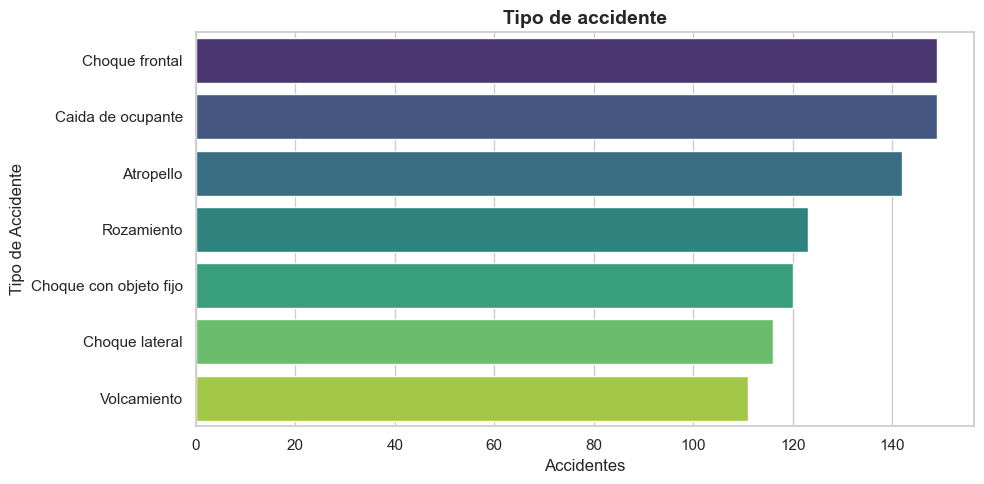

In [21]:
# Su código aquí
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_limpio, 
    y='tipo_accidente', 
    order=df_limpio['tipo_accidente'].value_counts().index, 
    palette='viridis'
)

plt.title('Tipo de accidente', fontsize=14, fontweight='bold')
plt.xlabel('Accidentes', fontsize=12)
plt.ylabel('Tipo de Accidente', fontsize=12)
plt.tight_layout()
plt.show()

**✏️ Interpretación Gráfico 1:**
Muestra el tipo de siniestro y cuantos accidentes hay de cada uno

### Gráfico 2


**✏️ Interpretación Gráfico 2:**
Muestra la cantidad de accidentes que hay en el mes

### Gráfico 3


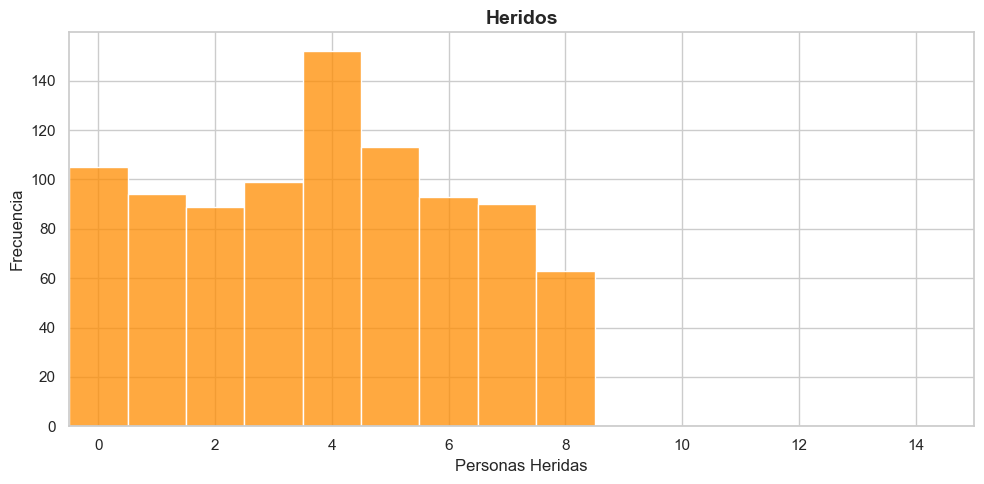

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_limpio, x='heridos', color='darkorange', discrete=True)
plt.title('Heridos', fontsize=14, fontweight='bold')
plt.xlabel('Personas Heridas', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xlim(-0.5, 15)
plt.tight_layout()
plt.show()

**✏️ Interpretación Gráfico 3:**


---

# PARTE 7: EXPORTAR RESULTADOS A SQL SERVER _(5 puntos)_

Exporte el DataFrame **`df_limpio`**
a una tabla llamada **`resumen_accidentes_transito`** en su instancia local de SQL Server, para ello debe crear una base de datos llamada **`Accidentes`** . Luego para confirmar, extraiga los datos de dicha tabla y cargue los datos en un dataframe llamado, df_accidentes_sql_server y muestre en pantalla los primeros 50 registros.


In [23]:

conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=LAPTOP-TQ4180D1;'
    'DATABASE=Accidentes;'
    'Trusted_Connection=yes;'
)
params = urllib.parse.quote_plus(conn_str)
engine = create_engine(
    f'mssql+pyodbc:///?odbc_connect={params}'
)
df_limpio.to_sql(
    'resumen_accidentes_transito',
    con=engine,
    schema='dbo',
    if_exists='replace',
    index=False
)
df_accidentes_sql_server = pd.read_sql(
    'select * from dbo.resumen_accidentes_transito',
    engine
)
display(df_accidentes_sql_server.head(50))

,id_accidente,fecha,provincia,canton,tipo_accidente,causa_probable,gravedad,victimas_fatales,heridos,vehiculos_involucrados,condicion_climatica,tipo_via,origen,id,nombre_feriado,anio,mes,dia_semana
0,1.0,2019-07-11,Guayas,Daule,Choque lateral,Estado de embriaguez,Leve,0.0,4.0,1.0,Soleado,Desconocido,CSV,765.5,Desconocido,2019,7,Jueves
1,2.0,2019-07-29,Manabi,Portoviejo,Volcamiento,Distraccion del conductor,Fatal,5.0,7.0,1.0,Soleado,Autopista,CSV,765.5,Desconocido,2019,7,Lunes
2,3.0,2022-12-13,El Oro,Machala,Choque frontal,Fallas mecanicas,Grave,1.0,0.0,4.0,Lluvioso,Rural,CSV,765.5,Desconocido,2022,12,Martes
3,4.0,2022-06-01,El Oro,Pasaje,Rozamiento,Cansancio del conductor,Grave,0.0,1.0,3.0,Lluvioso,Urbana,CSV,765.5,Desconocido,2022,6,Miércoles
4,5.0,2021-04-01,Manabi,Chone,Choque frontal,No respetar seniales,Leve,0.0,4.0,2.0,Lluvioso,Autopista,CSV,765.5,Desconocido,2021,4,Jueves
5,6.0,2021-05-27,El Oro,Zaruma,Volcamiento,Mal estado de la via,Leve,0.0,7.0,4.0,Nublado,Secundaria,CSV,765.5,Desconocido,2021,5,Jueves
6,7.0,2021-02-27,Manabi,El Carmen,Rozamiento,Cansancio del conductor,Leve,0.0,2.0,1.0,Neblina,Urbana,CSV,765.5,Desconocido,2021,2,Sábado
7,8.0,2021-10-22,El Oro,Pasaje,Rozamiento,No respetar seniales,Fatal,5.0,0.0,3.0,Soleado,Autopista,CSV,765.5,Desconocido,2021,10,Viernes
8,9.0,2020-05-05,El Oro,Machala,Choque lateral,Distraccion del conductor,Grave,2.0,3.0,1.0,Soleado,Autopista,CSV,765.5,Desconocido,2020,5,Martes
9,10.0,2021-05-16,Guayas,Daule,Rozamiento,Distraccion del conductor,Grave,2.0,1.0,2.0,Lluvioso,Secundaria,CSV,765.5,Desconocido,2021,5,Domingo
